1. Write Python functions for the sigmoid, tanh, and ReLU activation functions that take a single float as input and return the output value.

In [1]:
import math

In [2]:
def sigmoid(x):
    return 1/(1+ math.exp(-x))

In [3]:
def tanh(x):
    return math.tanh(x)

In [4]:
def relu(x):
    if x> 0 :
        return x
    else:
        return 0

In [5]:
x = 2.5 

In [6]:
print("Input: ", x)
print("Sigmoid function on x :",sigmoid(x))
print("Tanh function on x: ",tanh(x))
print("Relu function on x: ", relu(x))

Input:  2.5
Sigmoid function on x : 0.9241418199787566
Tanh function on x:  0.9866142981514303
Relu function on x:  2.5


2. Use matplotlib to plot the graphs of sigmoid, tanh, and ReLU functions on the same figure for input values ranging from -10 to 10.<br><br><em><strong>Hint:</strong> Use numpy to generate input values and label each curve clearly.</em>

In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
x = np.linspace(-10,10,50)

In [9]:
sigmoid_output = [sigmoid(i) for i in x]
tanh_output =[tanh(i) for i in x]
relu_output = [relu(i) for i in x]

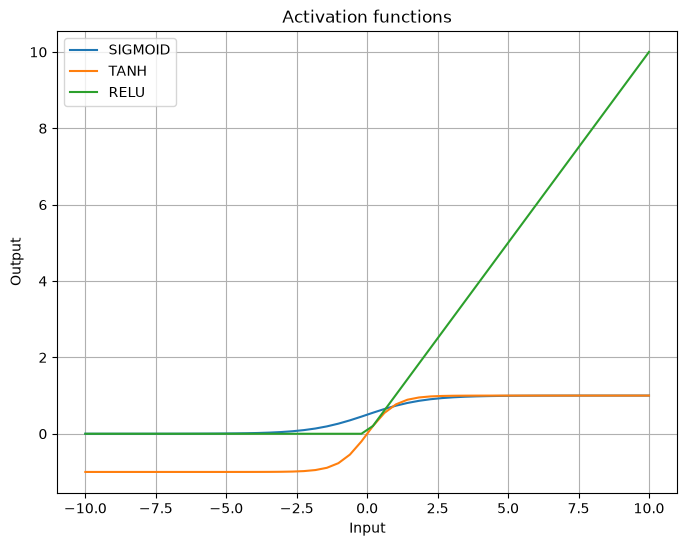

In [10]:
plt.figure(figsize= (8,6))
plt.plot(x, sigmoid_output,label ="SIGMOID")
plt.plot(x, tanh_output,label ="TANH")
plt.plot(x, relu_output,label ="RELU")

plt.title("Activation functions")
plt.xlabel("Input")
plt.ylabel("Output")

plt.grid(True)
plt.legend()

plt.show()

3. Simulate the vanishing gradient problem by calculating and printing the derivative of the sigmoid function for input values between -10 and 10. Observe and explain where the gradient becomes very small.

In [11]:
def sigmoid_derivative(x):
    s= sigmoid(x)
    return s*(1-s)

In [12]:
print("Input\t Sigmoid derivative")
for value in x:
    print(f"{value:.1f}\t{sigmoid_derivative(value):.6f}")

Input	 Sigmoid derivative
-10.0	0.000045
-9.6	0.000068
-9.2	0.000103
-8.8	0.000154
-8.4	0.000232
-8.0	0.000349
-7.6	0.000525
-7.1	0.000789
-6.7	0.001186
-6.3	0.001782
-5.9	0.002675
-5.5	0.004013
-5.1	0.006011
-4.7	0.008986
-4.3	0.013393
-3.9	0.019870
-3.5	0.029284
-3.1	0.042734
-2.7	0.061471
-2.2	0.086615
-1.8	0.118549
-1.4	0.155948
-1.0	0.194751
-0.6	0.227962
-0.2	0.247415
0.2	0.247415
0.6	0.227962
1.0	0.194751
1.4	0.155948
1.8	0.118549
2.2	0.086615
2.7	0.061471
3.1	0.042734
3.5	0.029284
3.9	0.019870
4.3	0.013393
4.7	0.008986
5.1	0.006011
5.5	0.004013
5.9	0.002675
6.3	0.001782
6.7	0.001186
7.1	0.000789
7.6	0.000525
8.0	0.000349
8.4	0.000232
8.8	0.000154
9.2	0.000103
9.6	0.000068
10.0	0.000045


Explanation:

This demonstrates the vanishing gradient problem. During backpropagation, weight updates are proportional to the derivative of the activation function. When the derivative is very close to 0 (for very large positive or negative inputs), the weight updates become extremely small. In deep neural networks, these tiny gradients can become even smaller as they are propagated through multiple layers, causing the early layers to learn very slowly or stop learning altogether.

4. Create a function that demonstrates the 'dying ReLU' problem by passing an array of negative values through the ReLU function and showing the output.<br><br><em><strong>Hint:</strong> Print both the input and output arrays to highlight the effect.</em>

In [13]:
def relu(x):
    return np.maximum(0, x)

In [14]:
def dying_relu():
    inputs = np.array([-10,-8,-6,-4,-2,-1])
     
    output = relu(inputs)

    print("Inputs:",inputs)
    print("Output:",output)

    print("\nExplanation:")
    print("All negative input values become 0 after passing through the ReLU function.")
    print("Since the output is 0, the gradient is also 0 during backpropagation.")
    print("As a result, these neurons stop updating their weights and become 'dead',")
    print("which is known as the Dying ReLU problem.")


In [15]:
dying_relu()

Inputs: [-10  -8  -6  -4  -2  -1]
Output: [0 0 0 0 0 0]

Explanation:
All negative input values become 0 after passing through the ReLU function.
Since the output is 0, the gradient is also 0 during backpropagation.
As a result, these neurons stop updating their weights and become 'dead',
which is known as the Dying ReLU problem.


5. Pick any activation function (sigmoid, tanh, or ReLU) and modify its Python implementation to add a parameter that scales the input (e.g., f(x) = sigmoid(a*x) where 'a' is a new parameter). Plot and compare the original and modified activation functions using matplotlib.

In [16]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [17]:
def modified_sigmoid(x,a):
    return 1/(1+np.exp(a*-x))

In [19]:
x = np.linspace(-10,10,50)
y_original = sigmoid(x)
y_modified = modified_sigmoid(x,a=2)

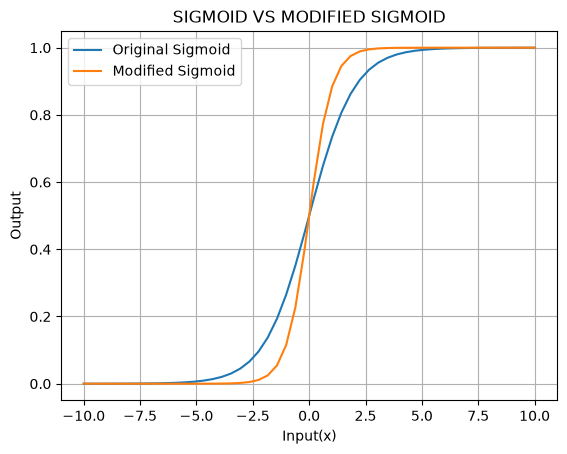

In [21]:
plt.plot(x,y_original,label="Original Sigmoid")
plt.plot(x,y_modified,label ="Modified Sigmoid")
plt.title("SIGMOID VS MODIFIED SIGMOID")
plt.xlabel("Input(x)")
plt.ylabel("Output")
plt.grid()
plt.legend()
plt.show()